<a class = "anchor" id="introduction-tp"></a>
# 🔐 TP : chiffrement par bloc, confusion et diffusion. 

Bienvenue dans ce TP ! L'objectif de cette séance est de démystifier le fonctionnement interne des algorithmes de chiffrement par bloc. Nous allons également visualiser et manipuler concrètement les concepts fondateurs introduits par Claude Shannon : la **confusion** et la **diffusion**. 

Grâce à un algorithme "jouet" et des outils interactifs, vous allez pouvoir observer de vos propres yeux ce qu'est l'**effet avalanche** et comment les mathématiques protègent l'information.

Chaque section vous propose une interaction avec le code ainsi qu'un petit exercice pour poussez votre compréhension un cran plus loin. Il n'est pas nécessaire de savoir programmer pour utiliser ce notebook. 

### 📑 Sommaire

* [Modèle jouet : chiffrer et déchiffrer](#modele-jouet)
* [Confusion : observation des corrélations](#confusion)
* [Diffusion : observer l'effet d'avalanche](#diffusion)
* [Exercice final :](#exercice-final)

---
*Astuce de navigation : Vous trouverez un lien "⬆️ Retour en haut" à la fin de chaque section pour revenir rapidement à ce sommaire.* </br>
*Une partie du code et des commentaires de ce notebook ont été écrits avec l'aide d'une IA.*
 

In [5]:
# Executez cette cellule en premier
%run TP-BlockCipher-functions.ipynb


<div style="background-color: #cce5ff; color: #004085; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">

<a class = "anchor" id="modele-jouet"></a>

# 1. Modèle jouet : chiffrer et déchiffrer

Dans la cellule suivante nous construisons l'algorithme de chiffrement par bloc très simplifié du cours (section 3.1.2). Ceci nous permet d'illustrer les opérations de base : la confusion ainsi que la diffusion et l'effet d'avalanche. Le chiffrement est défini par la fonction encrypt qui prend en entrée une chaîne de longueur 8 bits et une clé de longueur 8 bits et donne en sortie une chaîne de 8 bits : le texte chiffré. 

Si le mode `verbose = True` est activé, l'algorithme affiche les états intermédiaires ainsi que les clés de tour utilisées. 
</div>

<br>

<div style="background-color: #406b82; color: #fffcfc; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">
    
**Exercice :**

Testez le chiffrement de différentes chaînes avec différentes clés. Pouvez-vous facilement trouver des points fixes de cet algorithme de chiffrement? On cherche des chaînes de bits qui pour une clé donnée sont envoyées sur elle-même. 

</div>

<br>

[⬆️ Retour au sommaire](#introduction-tp)

In [7]:
def bit_string_to_list(bit_str):
    return [int(b) for b in bit_str]

def list_to_bit_string(bit_list):
    return "".join(str(b) for b in bit_list)

def apply_permutation(bits, p_table):
    # p_table utilise des positions de 1 à 8 (notation LaTeX)
    return [bits[i-1] for i in p_table]

def apply_substitution(bits):
    # On découpe l'octet en 4 paires de 2 bits
    # f: 00->10, 01->11, 10->10, 11->00
    s_box = {
        (0,0): (0,1),
        (0,1): (1,1),
        (1,0): (1,0),
        (1,1): (0,0)
    }
    new_bits = []
    for i in range(0, 8, 2):
        pair = tuple(bits[i:i+2])
        new_bits.extend(s_box[pair])
    return new_bits

def get_sub_key(master_key, round_num):
    # Décalage circulaire vers la droite de 'round_num' rangs
    n = len(master_key)
    shift = round_num % n
    return master_key[-shift:] + master_key[:-shift]

def xor_lists(list1, list2):
    return [b1 ^ b2 for b1, b2 in zip(list1, list2)]

def encrypt(plaintext_str, key_str, rounds=4, verbose=False):
    state = bit_string_to_list(plaintext_str)
    master_key = bit_string_to_list(key_str)
    
    # Table de permutation
    p_table = [3, 1, 5, 7, 2, 8, 6, 4]
    
    # Affichage conditionnel
    if verbose:
        print(f"--- Début du chiffrement ---")
        print(f"Entrée : {plaintext_str}")
    
    for i in range(1, rounds + 1):
        # 1. Permutation
        state = apply_permutation(state, p_table)
        
        # 2. Substitution
        state = apply_substitution(state)
        
        # 3. Ajout de la sous-clé (XOR)
        ki = get_sub_key(master_key, i)
        state = xor_lists(state, ki)
        
        # Affichage conditionnel pour chaque tour
        if verbose:
            print(f"Tour {i} | Sous-clé k{i}: {list_to_bit_string(ki)} | Sortie: {list_to_bit_string(state)}")
            
    return list_to_bit_string(state)

# --- Test de l'exemple ---
x = "00000000"
k = "00000000"
resultat = encrypt(x, k,verbose = True)


--- Début du chiffrement ---
Entrée : 00000000
Tour 1 | Sous-clé k1: 00000000 | Sortie: 01010101
Tour 2 | Sous-clé k2: 00000000 | Sortie: 01010000
Tour 3 | Sous-clé k3: 00000000 | Sortie: 01011011
Tour 4 | Sous-clé k4: 00000000 | Sortie: 01000011


In [2]:
# A vous de jouer : chercher des points fixes de ce chiffrement

x = "11111111"
k = "11111111"
resultat = encrypt(x,k)
print(resultat)







11111111


<div style="background-color: #cce5ff; color: #004085; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">
<a class = "anchor" id="confusion"></a>
    
### 1.1 Confusion : observation des corrélations

La prochaine cellule va permettre de tester la confusion générée par notre algorithme jouet : nous allons examiner les corrélations entre les bits du texte clair et les bits de texte chiffrés pour une clé donnée. Cette corrélation est une mesure de ressemblance comprise entre -1 et 1. Nous allons également observer la corrélation entre la clé et le texte chiffré.  

**Comment interpréter une valeur de corrélation?**
* Une valeur de -1 signifie que les deux bits concernés prennent toujours des états différents : quand l'un vaut 1, l'autre vaut systématiquement O.
* Une valeur de 1 signifie que les deux bits ont toujours le même état. Une valeur de 0 signifie que l'état d'un bit semble n'avoir aucune influence sur l'état de l'autre.
* Une valeur de 0.5 signifie que les deux bits partagent le même état bien plus souvent que le hasard ne le voudrait même si ça n'est pas systématique : les bits sont corrélés.


**La fonction `analyze_correlation(k,N)` :**
* Elle prend en entrée une valeur de clé k, un entier N qui est le nombre d'échantillons sur lequel le test statistique est réalisé. Si `display = False`la fonction n'affiche pas les matrices de corrélations. 
</div>

<br>

<div style="background-color: #406b82; color: #fffcfc; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">
    
**Exercice :**

Cherchez une valeur de clé pour laquelle l'algorithme de chiffrement présente de mauvaises propriétés de confusion : le texte chiffré et le texte en clair présente des corrélations significatives. 
</div>

<br>

[⬆️ Retour au sommaire](#introduction-tp)

In [3]:
# ----- Exemple d'utilisation ------
k_test = "11110000"
pt_fixe = "11110000"
matrice_in, matrice_key = analyze_correlations(k=k_test,pt_fixe = pt_fixe, N=1024, display=True)

NameError: name 'analyze_correlations' is not defined

In [ ]:
# A vous de jouer ! Chercher des valeurs de k_test et de pt_fixe pour 
# lesquelles les entrées / sorties ou les sorties / clés sont particulièrement corrélées.

k_test = ""
pt_fixe = ""
#matrice_in, matrice_key = analyze_correlations(k=k_test,pt_fixe = pt_fixe, N=1024, display=True)











<div style="background-color: #cce5ff; color: #004085; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">
<a class = "anchor" id="diffusion"></a>
    
### 1.2 Diffusion : observer l'effet d'avalanche  (`avalanche_visualizer`)

Nous allons maintenant tenter de visualiser la capacité de notre cipher à diffuser la modification d'un seul bit d'entrée vers au moins la moitié des bits de sortie. 

Cette application interactive permet d'observer en temps réel le comportement de **l'effet avalanche**, une propriété fondamentale des bons algorithmes de chiffrement stipulant qu'une modification minimale en entrée doit produire un bouleversement complet en sortie.

**Fonctionnement :**
* **Interactivité :** L'interface présente la clé de chiffrement et deux textes clairs sous forme de grilles de bits cliquables (Noir = `1`, Blanc = `0`).
* **Calcul en temps réel :** Cliquer sur n'importe quel bit (texte ou clé) recalcule instantanément les textes chiffrés correspondants.
* **Analyse visuelle :** Des indicateurs rouges (🔴) apparaissent dynamiquement sous les bits des textes chiffrés qui ont basculé suite à votre dernière modification, illustrant ainsi les notions de *diffusion* et de *confusion* cryptographiques.

</div>

<br>

<div style="background-color: #406b82; color: #fffcfc; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">
    
**Exercice :**

Observez l'effet d'avalanche. Vous pourrez essayer de répondre aux questions suivantes empiriquement : 
* Pour une clé fixée, combien de bits de sortie changent en moyenne lorsque vous modifiez un bit d'entrée?
* Pouvez-vous trouver deux entrées proches telles que les sorties soient également proches?
* La clé influe-t-elle sur l'effet d'avalanche? Certaines clés sont-elles plus faibles que d'autres?
* Pouvez-vous trouver des bits plus faibles que d'autres, c'est à dire dont la modification à tendance à entraîner moins de changement que les autres? 
</div>

<br>

[⬆️ Retour au sommaire](#introduction-tp)

In [8]:
# Exemple d'utilisation : 

root = tk.Tk()
pt1_start = "00000000"
pt2_start = "11111111"
key_start = "00000000"
    
app = avalanche_visualizer(root, pt1_start, pt2_start, key_start)
root.mainloop()

<div style="background-color: #406b82; color: #fffcfc; padding: 15px; border-left: 5px solid #0056b3; border-radius: 5px;">
<a class = "anchor" id="exercice-final"></a>
    
**Exercice :**

Reprenez toutes les étapes précédentes en modifiant le block cipher pour essayer de le rendre plus faible (c'est à dire diminuer sa capacité de diffusion et de confusion). Les paramètres sur lesquels vous pouvez jouer sont : 
* La permutation
* La fonction de substitution
* Le nombre de tour
* L'ordonnancement des clés.

En utilisant votre cours, essayez de faire des mauvais choix qui ne soient pas triviaux. Vérifier alors que vous diminuer la sécurité de l'algorithme.  
</div>

<br>

[⬆️ Retour au sommaire](#introduction-tp)

# Les Modes d'Opération du Chiffrement par Bloc (AES)

Un algorithme comme **AES** est un "chiffrement par bloc" : il ne sait transformer qu'un morceau de données de taille fixe (128 bits) en un autre morceau de 128 bits. Pour chiffrer un fichier entier (comme une image), nous devons définir comment "enchaîner" ces blocs.

### 1. ECB (Electronic Codebook) - Le mode "Naïf"
C'est le mode le plus simple : chaque bloc est chiffré indépendamment avec la même clé $K$.
* **Équation** : $C_i = E_K(P_i)$
* **Défaut majeur** : Il est **déterministe**. Si deux blocs de texte clair sont identiques ($P_1 = P_2$), les blocs chiffrés seront identiques ($C_1 = C_2$). Cela préserve les motifs structurels des données (comme on le voit sur les images).

### 2. CBC (Cipher Block Chaining) - L'enchaînement classique
Pour casser le déterminisme, chaque bloc de texte clair est combiné (via un XOR) avec le bloc chiffré précédent avant d'être chiffré. On utilise un **Vecteur d'Initialisation (IV)** aléatoire pour le premier bloc.
* **Équation** : $C_i = E_K(P_i \oplus C_{i-1})$
* **Avantage** : Deux blocs identiques ne donneront jamais le même résultat chiffré.
* **Inconvénient** : Le chiffrement n'est pas parallélisable (on a besoin de $C_{i-1}$ pour calculer $C_i$).

### 3. CTR (Counter Mode) - Le chiffrement "Flux"
Le mode compteur transforme le chiffrement par bloc en un chiffrement par flux. On chiffre une valeur de compteur qui s'incrémente pour chaque bloc, puis on fait un XOR entre le résultat et le texte clair.
* **Équation** : $C_i = P_i \oplus E_K(\text{Nonce} || \text{Counter})$
* **Avantage** : Très rapide, totalement parallélisable et ne nécessite pas de "padding" (remplissage).
* 
### 4. GCM (Galois/Counter Mode) - Le standard moderne (AEAD)
Le mode GCM est ce qu'on appelle un mode **AEAD** (*Authenticated Encryption with Associated Data*). Contrairement à CBC ou CTR qui ne font que "cacher" l'information (confidentialité), GCM garantit aussi que l'information n'a pas été modifiée (intégrité/authenticité).

* **Fonctionnement** : Il utilise le mode CTR pour le chiffrement et y ajoute un code d'authentification (Tag) calculé par une multiplication dans un corps de Galois.
* **Avantages** : 
    * **Performance** : Totalement parallélisable et extrêmement rapide sur les processeurs modernes (grâce aux instructions matérielles AES-NI).
    * **Sécurité** : Si un attaquant modifie ne serait-ce qu'un bit du message chiffré, le déchiffrement échouera lors de la vérification du tag.
* **Inconvénient** : Comme pour CTR, la réutilisation d'un nonce (nombre unique) avec la même clé est catastrophique pour la sécurité.

---

In [9]:
# Faiblesse du mode ECB

# --- Paramètres de la démonstration ---
input_file = "secret.jpeg"      # Votre image source
output_file = "encrypted_ecb.jpeg" # L'image chiffrée résultante

# Générer une clé AES-128 (16 octets).
# Pour cette démo, on utilise une clé fixe, mais en production, elle doit être aléatoire.
key = b'sixteen byte key' # 16 octets

# Vérifier si l'image source existe, sinon en créer une de test
if not os.path.exists(input_file):
    print(f"L'image source '{input_file}' n'existe pas.")
    print("Création d'une image de test 'secret.jpeg' avec le texte 'TOP SECRET'...")
    # Créer une image blanche
    test_img = np.full((300, 600, 3), 255, dtype=np.uint8)
    # Ajouter le texte
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(test_img, 'TOP SECRET', (50, 180), font, 3, (0, 0, 0), 10, cv2.LINE_AA)
    cv2.imwrite(input_file, test_img)
    print("Image de test créée. Vous pouvez relancer le script.")
else:
    # Lancer le chiffrement
    encrypt_image_ecb(input_file, output_file, key)

--- Chiffrement de secret.jpeg avec AES-128-ECB ---
Dimensions de l'image : 1202x340 pixels, 3 canaux.
Taille des données brutes de l'image : 1226040 octets.
Ajout de 8 octets de padding.
Taille des données chiffrées : 1226048 octets.
Image chiffrée sauvegardée sous : encrypted_ecb.jpeg
Observez comment les motifs et le texte sont toujours visibles.


340 1202 3


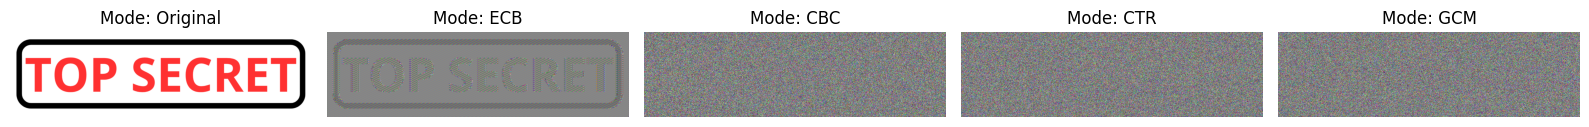

In [8]:
def encrypt_image(data, key, mode_name):
    # Génération d'un nonce/IV aléatoire (12 octets recommandé pour GCM)
    iv_or_nonce = os.urandom(12 if mode_name == "GCM" else 16)
    
    if mode_name == "ECB":
        cipher = Cipher(algorithms.AES(key), modes.ECB(), backend=default_backend())
    elif mode_name == "CBC":
        cipher = Cipher(algorithms.AES(key), modes.CBC(iv_or_nonce), backend=default_backend())
    elif mode_name == "CTR":
        cipher = Cipher(algorithms.AES(key), modes.CTR(iv_or_nonce), backend=default_backend())
    elif mode_name == "GCM":
        cipher = Cipher(algorithms.AES(key), modes.GCM(iv_or_nonce), backend=default_backend())
    
    encryptor = cipher.encryptor()
    
    # Padding uniquement pour ECB et CBC
    if mode_name in ["ECB", "CBC"]:
        pad_len = (16 - (len(data) % 16)) % 16
        data = data + b"\0" * pad_len
    
    encrypted_data = encryptor.update(data) + encryptor.finalize()
    
    # Pour GCM, on ignore le tag pour cette démo visuelle, mais en vrai, il est crucial !
    # tag = encryptor.tag
    
    return np.frombuffer(encrypted_data[:len(data)], dtype=np.uint8)



# 1. Charger l'image
img_path = "secret.jpeg"
if not os.path.exists(img_path):
    # Création d'une image par défaut si le fichier n'existe pas
    img = np.full((300, 600, 3), 255, dtype=np.uint8)
    cv2.putText(img, 'TOP SECRET', (50, 180), cv2.FONT_HERSHEY_SIMPLEX, 3, (0,0,0), 10)
else:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Conversion pour matplotlib

h, w, c = img.shape
print(h,w,c)
img_bytes = img.tobytes()
key = os.urandom(32) # AES-256

# 2. Chiffrer avec différents modes
modes_to_test = ["ECB", "CBC", "CTR", "GCM"]
results = {"Original": img}

for mode in modes_to_test:
    enc_flat = encrypt_image(img_bytes, key, mode)
    enc_flat_reshaped = enc_flat[0:h*w*c]
    results[mode] = enc_flat_reshaped.reshape((h, w, c))

# 3. Affichage des résultats
plt.figure(figsize=(16, 8))
for i, (name, image) in enumerate(results.items()):
    plt.subplot(1, 5, i+1)
    plt.imshow(image)
    plt.title(f"Mode: {name}")
    plt.axis('off')

plt.tight_layout()
plt.show()